# Advanced Analystics

This notebook presents advanced analytics on mutual fund data using Python and Pandas. It covers risk analysis, fund performance, investor behavior, portfolio concentration, and a simple fund recommendation system to derive meaningful financial insights.

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")
transactions = pd.read_csv("../data/processed/transactions_cleaned.csv")
scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")
portfolio = pd.read_csv("../data/processed/portfolio_holdings_cleaned.csv")

## Historical VaR (95%) and CVaR

In [20]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(by=["amfi_code","date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [21]:
nav['daily_return'] = (nav.groupby('amfi_code')['nav'].pct_change())
nav = nav.dropna(subset=['daily_return'])

In [22]:
results = []

for amfi, group in nav.groupby('amfi_code'):
    returns = group['daily_return']
    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()

    results.append({"amfi_code": amfi, "VaR_95": var95, "CVaR_95": cvar95})

In [23]:
var_cvar = pd.DataFrame(results)
var_cvar.to_csv("../data/processed/var_cvar_report.csv",index=False)
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


### Observation

Daily returns were calculated from the NAV values of each mutual fund scheme. Historical VaR (95%) was computed as the 5th percentile of the daily return distribution, while CVaR (95%) represents the average return below the VaR threshold. These metrics provide an estimate of the downside risk for each scheme.

## Rolling 90-Day Sharpe Ratio

In [24]:
fund_master = fund_master[['amfi_code', 'scheme_name']]
nav = nav.merge(fund_master, on='amfi_code', how='left')
top5 = nav['amfi_code'].unique()[:5]

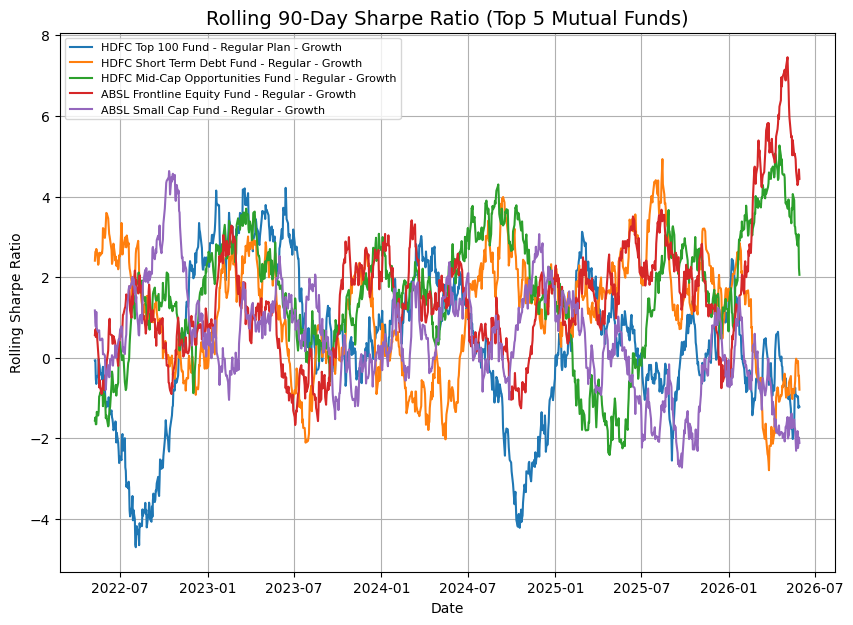

In [26]:
plt.figure(figsize=(10,7))

# Calculate Rolling Sharpe Ratio
for code in top5:
    fund = nav[nav['amfi_code'] == code].copy()

    rolling_mean = fund['daily_return'].rolling(window=90).mean()
    rolling_std = fund['daily_return'].rolling(window=90).std()

    fund['rolling_sharpe'] = (rolling_mean / rolling_std) * np.sqrt(252)

    scheme = fund['scheme_name'].iloc[0]

    plt.plot(fund['date'], fund['rolling_sharpe'], label=scheme)

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Mutual Funds)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.savefig("../reports/charts/rolling_sharpe_chart.png", dpi=300)

plt.show()

### Observation

The rolling 90-day Sharpe Ratio varied considerably across the five selected mutual fund schemes, indicating changes in their risk-adjusted performance over time. Most funds experienced periods of both positive and negative Sharpe Ratios, reflecting fluctuations in market conditions. A few schemes maintained relatively higher Sharpe Ratios for extended periods, suggesting better risk-adjusted returns, while others showed greater volatility with frequent declines below zero.

## Investor Cohort Analysis.

In [37]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

In [35]:
print(transactions['transaction_type'].value_counts())

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [38]:
sip = transactions[transactions['transaction_type'] == 'SIP'].copy()

sip = sip.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
sip['cohort_year'] = (sip.groupby('investor_id')['transaction_date'].transform('min').dt.year)

avg_sip = (sip.groupby('cohort_year')['amount_inr'].mean().round(2))

total_invested = (sip.groupby('cohort_year')['amount_inr'].sum().round(2))

top_fund = (sip.groupby(['cohort_year', 'scheme_name']).size().reset_index(name='SIP_Count'))
top_fund = (top_fund.sort_values(['cohort_year', 'SIP_Count'],ascending=[True, False]).drop_duplicates('cohort_year'))

cohort_report = pd.DataFrame({'Average_SIP_Amount': avg_sip, 'Total_Invested': total_invested}).reset_index()
cohort_report = cohort_report.merge(top_fund[['cohort_year', 'scheme_name']], on='cohort_year', how='left')

cohort_report.rename(columns={'scheme_name': 'Top_Fund_Preference'}, inplace=True)

cohort_report.to_csv("../data/processed/investor_cohort_analysis.csv",index=False)

cohort_report

,cohort_year,Average_SIP_Amount,Total_Invested,Top_Fund_Preference
0,2024,10986.86,212189262,ABSL Small Cap Fund - Regular - Growth
1,2025,12516.70,5044229,SBI Small Cap Fund - Direct Plan - Growth


### Observation

The cohort analysis shows that investors who began SIP investments in **2024** contributed the highest total investment (₹21.22 crore), indicating stronger overall participation during that year. In contrast, the **2025** cohort had a higher average SIP amount (₹12,516.70), suggesting that newer investors are investing larger amounts per SIP. The most preferred schemes also differed between cohorts, reflecting changes in investor fund preferences over time.

## SIP Continuity Analysis

In [50]:
sip = sip.sort_values(['investor_id', 'transaction_date'])
sip['gap_days'] = (sip.groupby('investor_id')['transaction_date'].diff().dt.days)

eligible = (sip.groupby('investor_id').filter(lambda x: len(x) >= 6))

In [51]:
continuity = (eligible.groupby('investor_id')['gap_days'].mean().reset_index())

continuity['status'] = continuity['gap_days'].apply(lambda x: 'At Risk' if x > 35 else 'Regular')

continuity.rename(columns={'gap_days': 'average_gap_days'},inplace=True)

continuity.to_csv("../data/processed/sip_continuity_analysis.csv",index=False)
continuity.head()

,investor_id,average_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


### Observation

The analysis classified investors into **Regular** and **At Risk** categories based on the average gap between consecutive SIP transactions. Investors with an average gap greater than 35 days were identified as **At Risk**, while those maintaining shorter intervals demonstrated more consistent SIP investment behaviour.

## Sector HHI Concentration

In [58]:
portfolio = portfolio.merge(fund_master[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='left')

equity = portfolio[portfolio['category'].str.contains('Equity', case=False, na=False)].copy()

In [59]:
equity['weight'] = equity['weight_pct'] / 100

hhi = (equity.groupby(['amfi_code', 'scheme_name'])['weight'].apply(lambda x: (x**2).sum()).reset_index(name='HHI'))
hhi = hhi.sort_values(by='HHI',ascending=False)

In [60]:
hhi.to_csv("../data/processed/hhi_report.csv", index=False)
hhi.head()

,amfi_code,scheme_name,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,0.206448
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298


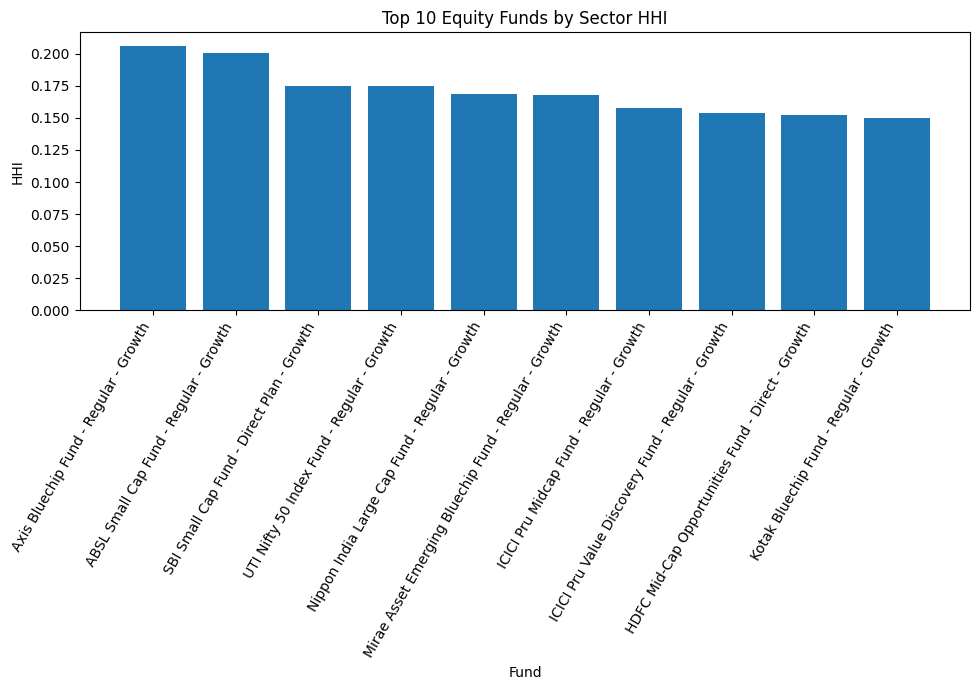

In [62]:
plt.figure(figsize=(10,7))

plt.bar(hhi.head(10)['scheme_name'], hhi.head(10)['HHI'])

plt.xticks(rotation=60, ha='right')

plt.title("Top 10 Equity Funds by Sector HHI")
plt.xlabel("Fund")
plt.ylabel("HHI")

plt.tight_layout()

plt.savefig("../reports/charts/hhi_chart.png",dpi=300)

plt.show()

### Observation

The HHI analysis indicates varying levels of sector concentration across equity mutual funds. The top-ranked funds have HHI values close to **0.20**, suggesting a relatively higher concentration of investments in a few sectors. In comparison, funds with lower HHI values are more diversified across sectors, which may help reduce concentration risk.

## Advanced Insights

1. **Risk Analysis:** Historical VaR and CVaR estimates highlight differences in downside risk across mutual fund schemes, helping identify funds with higher potential losses during adverse market conditions.

2. **Risk-Adjusted Performance:** The rolling 90-day Sharpe Ratio shows that fund performance changes over time, with some schemes consistently maintaining stronger risk-adjusted returns than others.

3. **Investor Behaviour:** Cohort analysis reveals differences in SIP investment patterns across investor groups, including variations in average SIP amount, total investment, and preferred mutual fund schemes.

4. **SIP Continuity:** Investors with an average gap exceeding 35 days between SIP transactions were identified as **At Risk**, indicating irregular investment behaviour that could impact long-term wealth creation.

5. **Portfolio Diversification:** Sector HHI analysis demonstrates that some equity funds are more concentrated in a limited number of sectors, while others maintain better diversification, providing investors with varying levels of concentration risk.